In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/X Level/data'

In [4]:
NUTS2 = 'Attica'
YEAR = '2009'

In [7]:
df = pd.read_csv(f'{base_folder}/GR_{NUTS2}_Timeline_{YEAR}_filled.csv', encoding=enc)

In [8]:
df.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-01,2009,1,2009-01-30,38.009965,23.767177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-01,38.009965,23.767177,14106.0,13846.0,2009-01-01,38.050174,23.750109,2008-12-31,2009-12-31,0.000000
1,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-02,2009,1,2009-01-30,38.009965,23.767177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-02,38.009965,23.767177,14106.0,13846.0,2009-01-02,38.050174,23.750109,2009-01-01,2009-01-01,2.866936
2,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-03,2009,1,2009-01-30,38.009965,23.767177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-03,38.009965,23.767177,14106.0,13846.0,2009-01-03,38.050174,23.750109,2009-01-02,2009-01-02,13.926683
3,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-04,2009,1,2009-01-30,38.009965,23.767177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-04,38.009965,23.767177,14106.0,13846.0,2009-01-04,38.050174,23.750109,2009-01-03,2009-01-03,2.439608
4,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-05,2009,1,2009-01-30,38.009965,23.767177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-05,38.009965,23.767177,14106.0,13846.0,2009-01-05,38.050174,23.750109,2009-01-04,2009-01-04,10.252046


<Axes: >

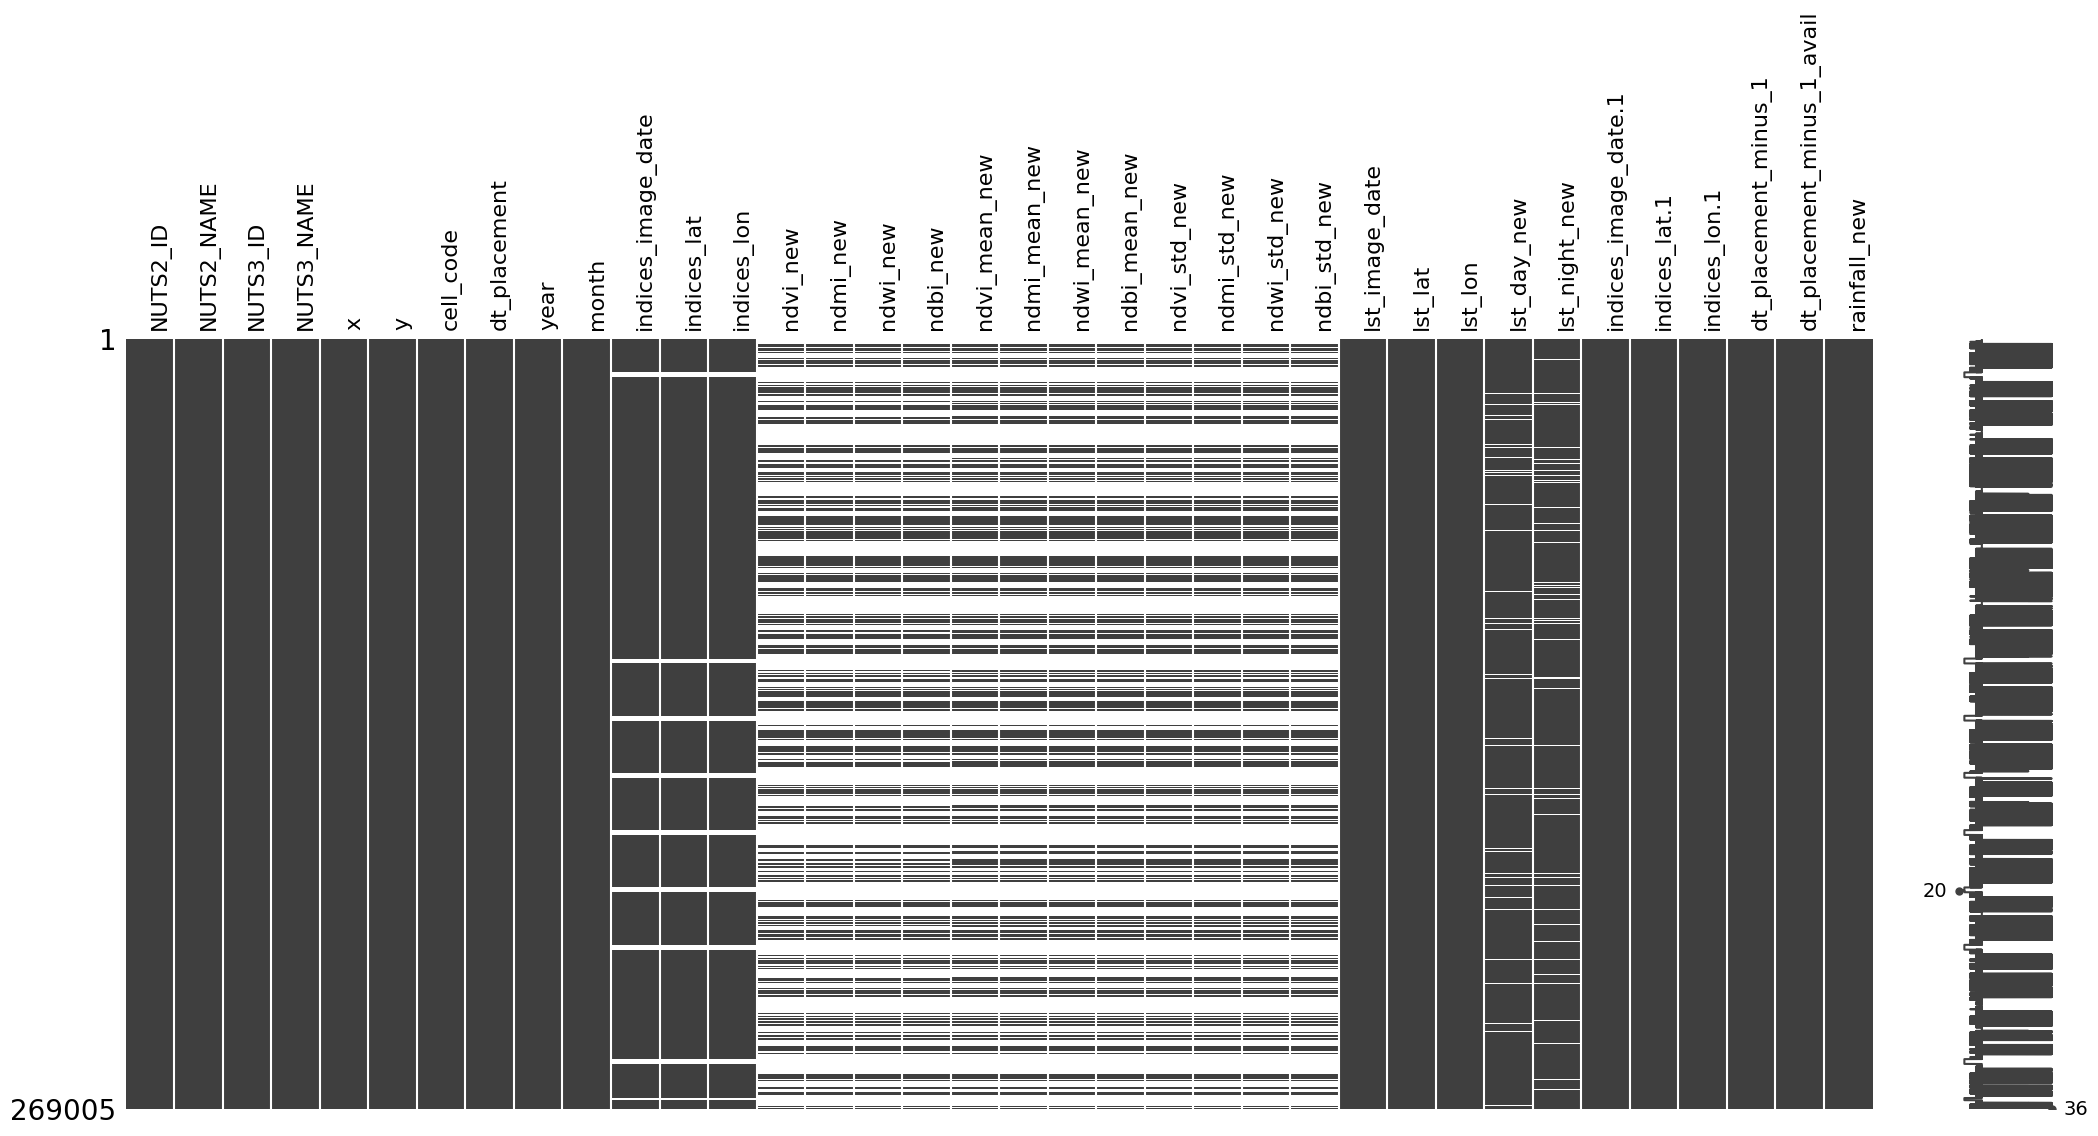

In [9]:
msno.matrix(df, label_rotation=90)

In [10]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)

In [11]:
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)

In [12]:
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [13]:
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [14]:
df

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,dt_placement,year,month,indices_image_date,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_day,lst_night,rainfall_image_date,rainfall
0,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-01,2009,1,2009-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-01,14106.0,13846.0,2009-12-31,0.000000
1,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-02,2009,1,2009-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-02,14106.0,13846.0,2009-01-01,2.866936
2,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-03,2009,1,2009-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-03,14106.0,13846.0,2009-01-02,13.926683
3,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-04,2009,1,2009-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-04,14106.0,13846.0,2009-01-03,2.439608
4,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-05,2009,1,2009-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-01-05,14106.0,13846.0,2009-01-04,10.252046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269000,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-27,2009,12,2009-12-07,0.156248,0.095192,-0.063144,-0.095192,0.111894,0.061901,-0.047648,-0.061901,0.039704,0.031216,0.020977,0.031216,2009-12-27,14393.0,14214.0,2009-12-26,2.433460
269001,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-28,2009,12,2009-12-07,0.156248,0.095192,-0.063144,-0.095192,0.111894,0.061901,-0.047648,-0.061901,0.039704,0.031216,0.020977,0.031216,2009-12-28,14490.0,14214.0,2009-12-27,3.405870
269002,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-29,2009,12,2009-12-07,0.156248,0.095192,-0.063144,-0.095192,0.111894,0.061901,-0.047648,-0.061901,0.039704,0.031216,0.020977,0.031216,2009-12-29,14490.0,14214.0,2009-12-28,1.391940
269003,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-30,2009,12,2009-12-07,0.156248,0.095192,-0.063144,-0.095192,0.111894,0.061901,-0.047648,-0.061901,0.039704,0.031216,0.020977,0.031216,2009-12-30,14490.0,14235.0,2009-12-29,0.000717


<Axes: >

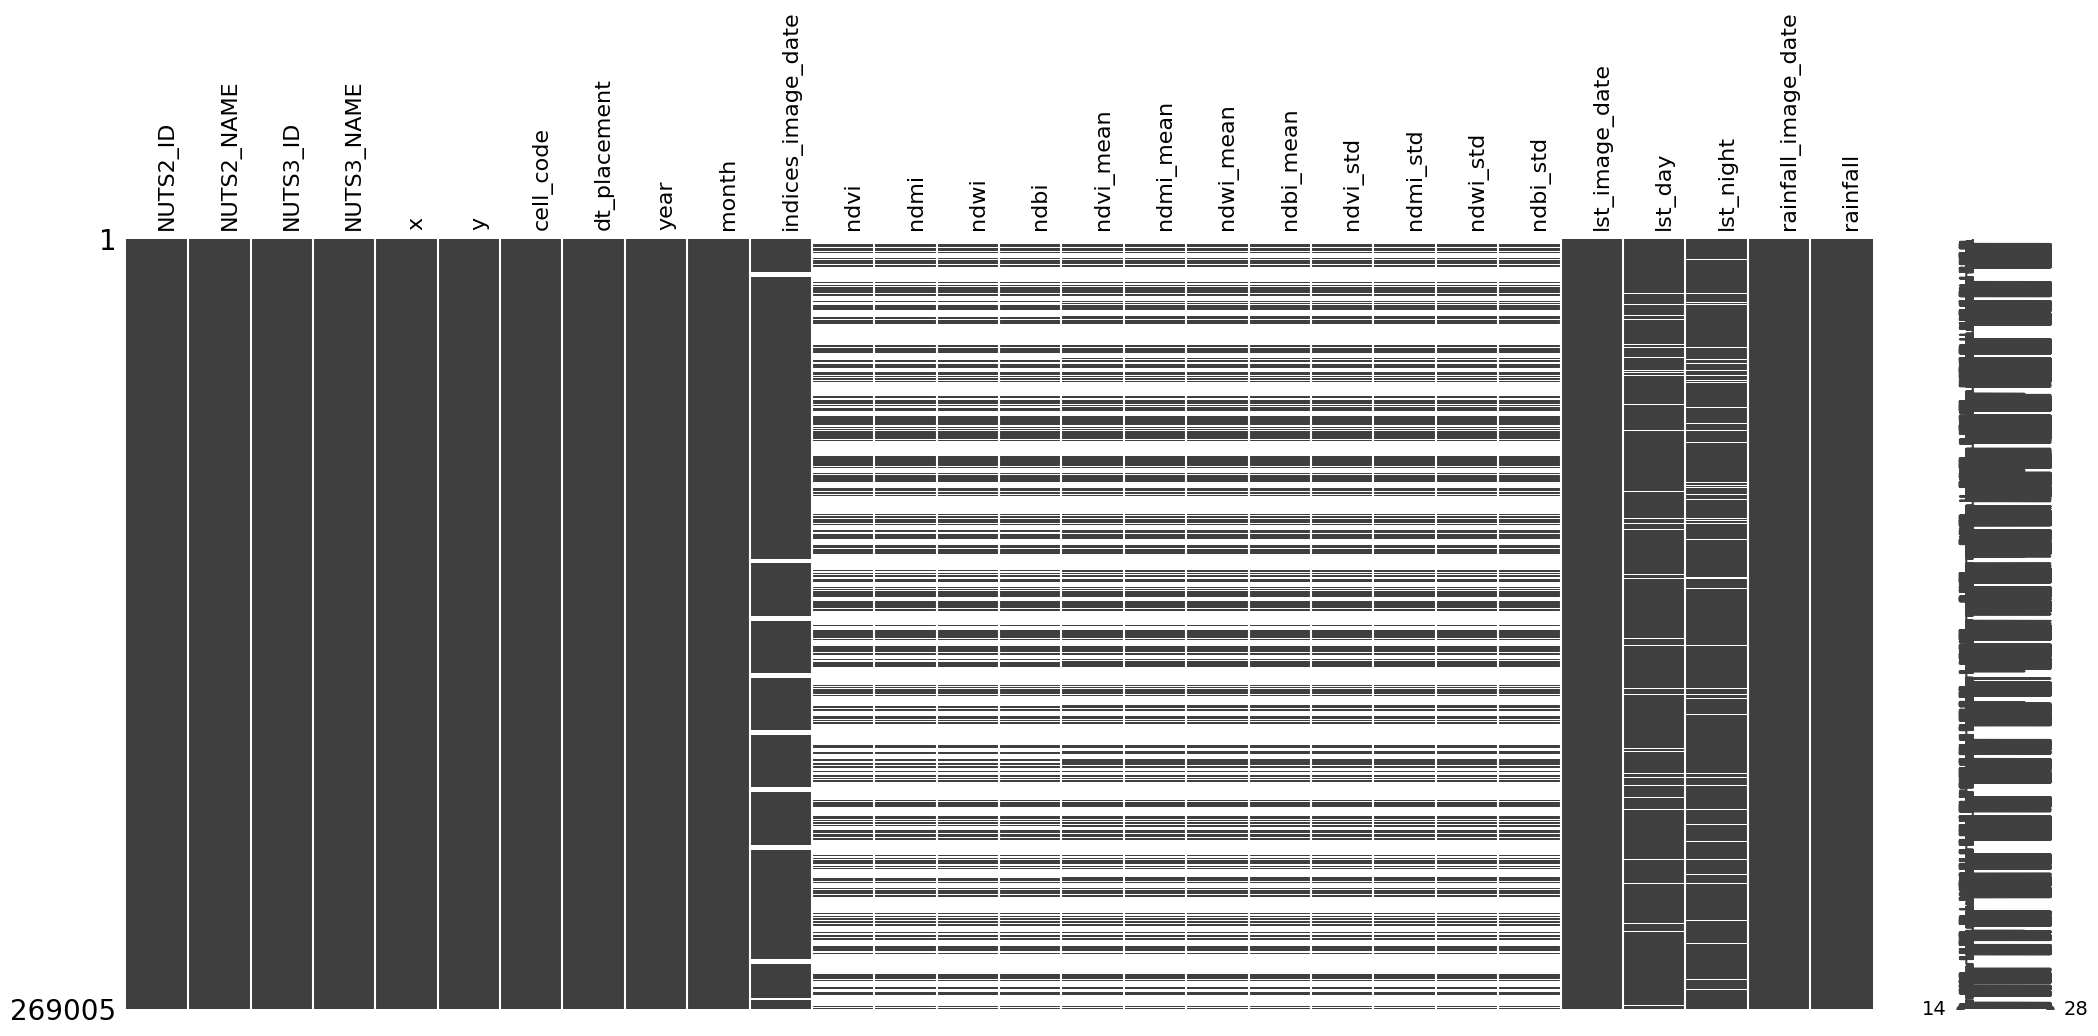

In [15]:
msno.matrix(df, label_rotation=90)

In [16]:
df2 = df.copy()

In [17]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

<Axes: >

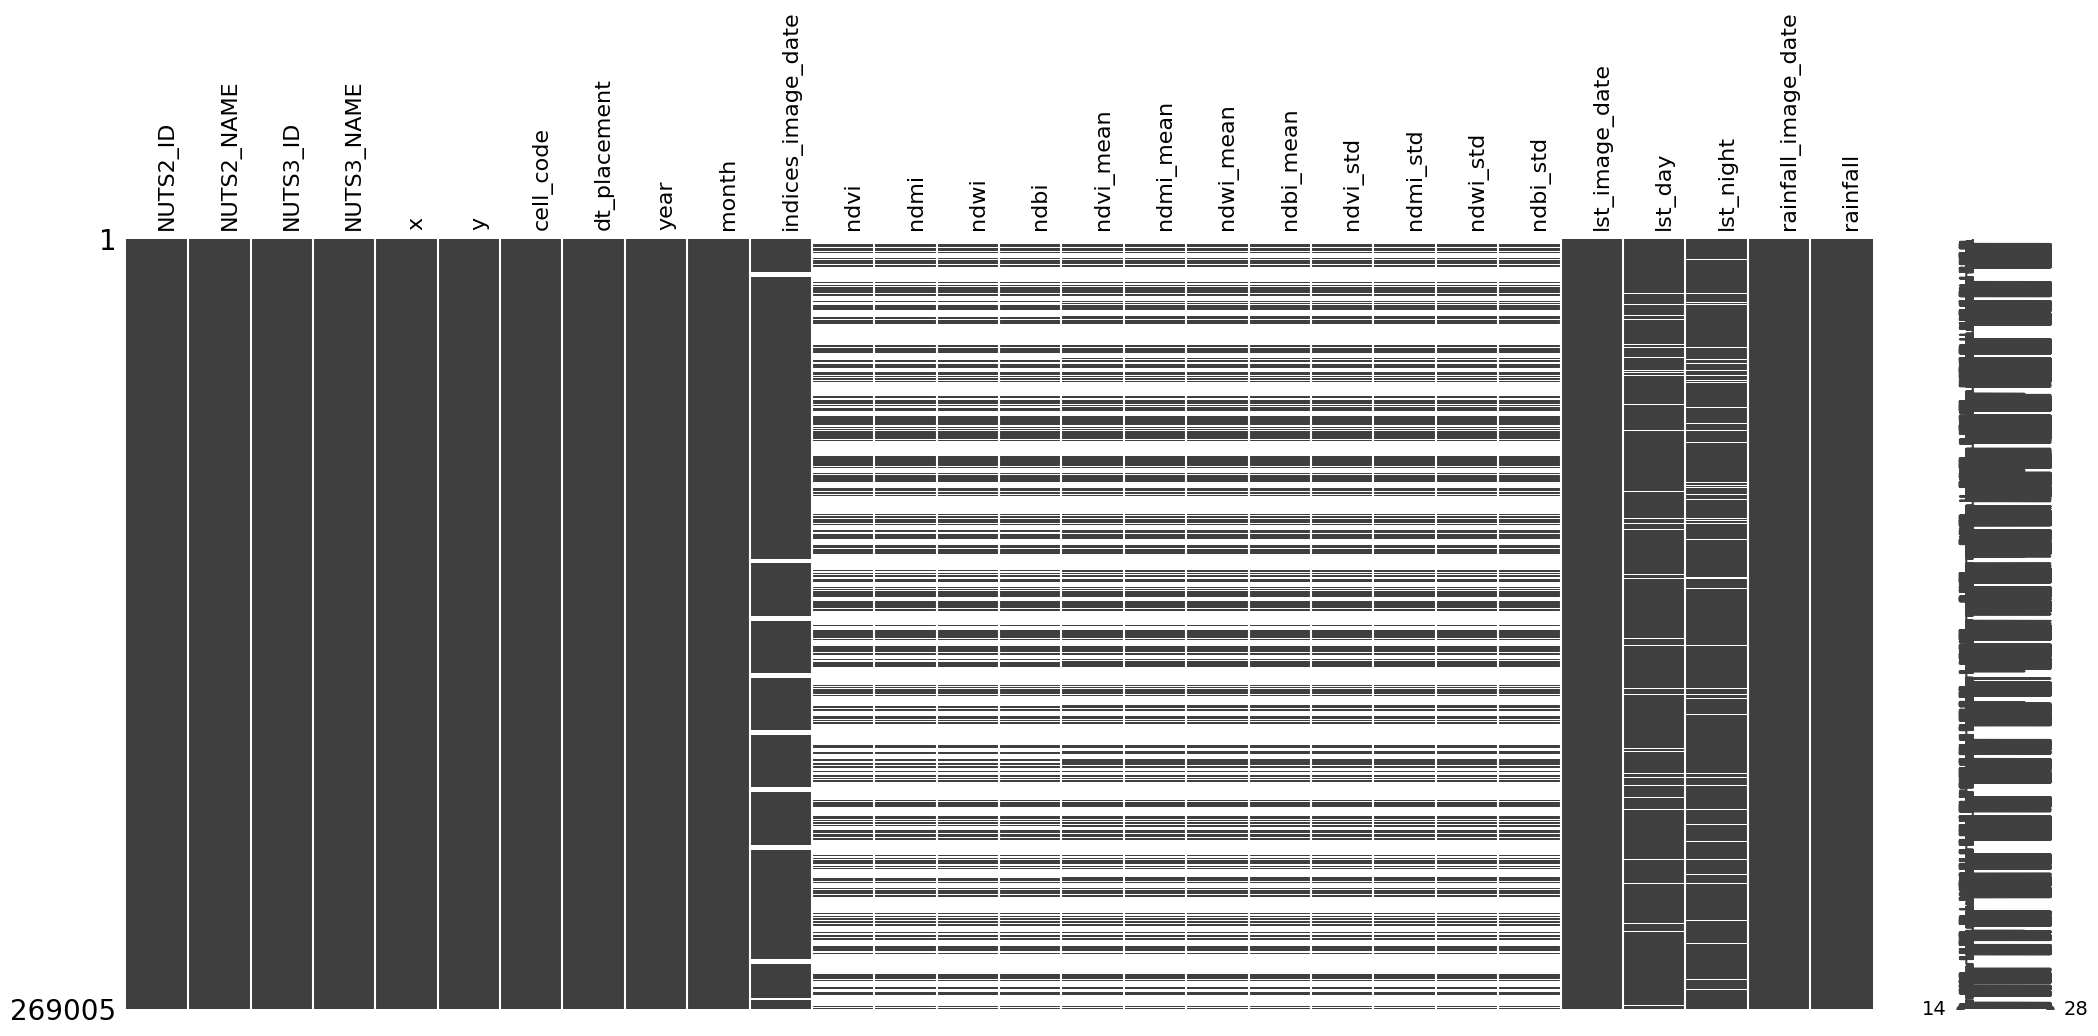

In [18]:
msno.matrix(df, label_rotation=90)

In [19]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,indices_image_date,5.3471
11,ndvi,68.6058
12,ndmi,68.6058
13,ndwi,68.6058
14,ndbi,68.6058
15,ndvi_mean,67.5489
16,ndmi_mean,67.5489
17,ndwi_mean,67.5489
18,ndbi_mean,67.5489
19,ndvi_std,67.5489


In [20]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [21]:
df2.reset_index(drop=True, inplace=True)

In [22]:
df2

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-01,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14106.0,13846.0,0.000000
1,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-02,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14106.0,13846.0,2.866936
2,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-03,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14106.0,13846.0,13.926683
3,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-04,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14106.0,13846.0,2.439608
4,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.76741,38.00793,EL301000001,2009-01-05,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14106.0,13846.0,10.252046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269000,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-27,2009,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14393.0,14214.0,2.433460
269001,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-28,2009,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14490.0,14214.0,3.405870
269002,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-29,2009,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14490.0,14214.0,1.391940
269003,EL30,αττικη,EL307,"πειραιας, νησοι",23.67877,37.97200,EL307000737,2009-12-30,2009,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14490.0,14235.0,0.000717


In [23]:
df2.to_csv(f'{base_folder}/GR_{NUTS2}_Timeline_{YEAR}_filled_cleaned.csv', encoding='utf-8')